# Q-CTRL Performance Management: prueba minima con Sampler

Este notebook comprueba el flujo minimo de Q-CTRL Performance Management sobre hardware real de IBM Quantum usando solamente `Sampler` y conteos. No usa `Estimator`.

El circuito logico es deliberadamente pequeno: una rotacion `RY(theta)` en un qubit medida en base computacional. Con `theta = 2 * asin(sqrt(0.2))`, la probabilidad ideal de medir `1` es aproximadamente `0.2`.

## 1. Imports minimos

La celda no detiene inmediatamente el notebook si falta `qiskit_ibm_catalog`; imprime un mensaje claro y deja que la celda de carga de Q-CTRL falle con una explicacion accionable.

In [1]:
from __future__ import annotations

import math
from collections.abc import Mapping
from typing import Any

import qiskit
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from IPython.display import display

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

try:
    from qiskit_ibm_catalog import QiskitFunctionsCatalog
except ModuleNotFoundError:
    QiskitFunctionsCatalog = None
    print(
        "ERROR: falta qiskit_ibm_catalog. Instala el paquete con:\n"
        "  pip install qiskit-ibm-catalog\n"
        "Q-CTRL Performance Management se carga desde Qiskit Functions Catalog."
    )

print("qiskit:", qiskit.__version__)

qiskit: 2.0.0


## 2. Configuracion

`ibm_basquecountry` queda como backend por defecto. Cambia `BACKEND_NAME` solo si tu cuenta no tiene acceso a ese sistema o si Q-CTRL no lo soporta para tu plan.

In [2]:
CHANNEL = "ibm_quantum_platform"
BACKEND_NAME = "ibm_basquecountry"
SHOTS = 1024

# Q-CTRL se ejecuta en un entorno serverless que puede llevar una version de
# Qiskit mas antigua que el kernel local. Qiskit 2.4 serializa por defecto
# QPY v17, que algunos entornos Q-CTRL aun no pueden leer. Para este circuito
# simple, QPY v13 es suficiente y mantiene mejor compatibilidad.
QCTRL_QPY_COMPAT_VERSION = 13

# Con esta eleccion, P(1) = sin(theta / 2)^2 = 0.2 idealmente.
theta = 2 * math.asin(math.sqrt(0.2))

# La comparacion raw es util, pero se puede desactivar para probar solo Q-CTRL.
RUN_RAW_RUNTIME_COMPARISON = True

print("backend por defecto:", BACKEND_NAME)
print("shots:", SHOTS)
print("theta:", theta)
print("QPY compat target para Q-CTRL:", QCTRL_QPY_COMPAT_VERSION)

backend por defecto: ibm_basquecountry
shots: 1024
theta: 0.9272952180016122
QPY compat target para Q-CTRL: 13


## 3. Utilidades pequeñas para counts

Qiskit Runtime V2 y Q-CTRL devuelven `PrimitiveResult` con `DataBin`. En circuitos con un registro clasico creado implicitamente por `measure`, los conteos suelen estar en `result[0].data.c.get_counts()`. Estas funciones mantienen la celda robusta ante nombres de registro como `c0`.

In [3]:
def object_name(obj: Any) -> str:
    """Return a readable backend/job name across Qiskit object versions."""

    name = getattr(obj, "name", None)
    if callable(name):
        return str(name())
    if name is not None:
        return str(name)
    return str(obj)


def job_identifier(job: Any) -> str:
    """Return a job id if the object exposes one, otherwise a clear fallback."""

    for attr in ("job_id", "job_id_"):
        value = getattr(job, attr, None)
        if callable(value):
            try:
                return str(value())
            except Exception:
                pass
        elif value is not None:
            return str(value)
    return "<sin job_id visible en el objeto>"


def normalize_counts(counts: Mapping[Any, Any]) -> dict[str, int]:
    """Normalize keys to compact bitstrings and values to plain ints."""

    return {str(key).replace(" ", ""): int(value) for key, value in counts.items()}


def extract_counts(result: Any) -> dict[str, int]:
    """Extract one-circuit counts from a SamplerV2/Q-CTRL PrimitiveResult."""

    pub_result = result[0]
    data = getattr(pub_result, "data", pub_result)

    # Common case for a circuit with one classical register named "c".
    for register_name in ("c", "c0"):
        register = getattr(data, register_name, None)
        if register is not None and hasattr(register, "get_counts"):
            return normalize_counts(register.get_counts())

    # Fallback: find any classical register-like object with get_counts().
    for attr in dir(data):
        if attr.startswith("_"):
            continue
        try:
            register = getattr(data, attr)
        except Exception:
            continue
        if hasattr(register, "get_counts"):
            return normalize_counts(register.get_counts())

    raise TypeError(f"No se pudieron extraer counts del resultado: {data!r}")


def p_hat_from_counts(counts: Mapping[str, int], shots: int) -> float:
    """Estimated success probability for measuring bitstring '1'."""

    return int(counts.get("1", 0)) / int(shots)


def force_qctrl_qpy_compat(version: int = 13) -> None:
    """Force qiskit-runtime JSON serialization to emit older QPY.

    Q-CTRL jobs are serialized locally and deserialized inside Q-CTRL's
    serverless environment. If the local Qiskit is newer than the remote one,
    the remote side can fail with: "QPY format version ... isn't supported".
    Lowering SERVICE_MAX_SUPPORTED_QPY_VERSION before submission makes the
    local serializer write an older QPY version for QuantumCircuit objects.
    """

    try:
        import qiskit_ibm_runtime.utils.json as runtime_json
    except Exception as exc:
        print("AVISO: no se pudo ajustar la version QPY de Runtime JSON.")
        print(f"Detalle: {type(exc).__name__}: {exc}")
        return

    local_qpy = getattr(runtime_json, "QISKIT_QPY_VERSION", None)
    service_qpy = getattr(runtime_json, "SERVICE_MAX_SUPPORTED_QPY_VERSION", None)
    target = int(version)

    runtime_json.SERVICE_MAX_SUPPORTED_QPY_VERSION = min(
        int(service_qpy or target),
        target,
    )

    print("QPY local Qiskit:", local_qpy)
    print("QPY max usado para serializar hacia Q-CTRL:", runtime_json.SERVICE_MAX_SUPPORTED_QPY_VERSION)


def print_qpy_error_hint(exc: Exception) -> None:
    """Print a focused hint for QPY client/server version mismatches."""

    msg = str(exc)
    if "QPY format version" not in msg:
        return

    print("\nERROR DE COMPATIBILIDAD QPY CLIENTE/SERVERLESS")
    print(
        "El circuito se serializo con una version QPY mas nueva que la "
        "soportada por el entorno serverless de Q-CTRL. Ejecuta de nuevo "
        "desde la celda de configuracion para aplicar QCTRL_QPY_COMPAT_VERSION=13."
    )
    print(
        "Si persiste, usa un entorno con qiskit<2.3 o contacta a Q-CTRL/IBM "
        "para confirmar la version QPY maxima soportada por tu funcion."
    )

## 4. Conexion a IBM Quantum y seleccion de backend

Esta celda usa exactamente `QiskitRuntimeService(channel="ibm_quantum_platform")`. Si `ibm_basquecountry` no esta disponible para la cuenta, lista algunos backends accesibles.

In [4]:
service = QiskitRuntimeService(channel=CHANNEL)
print("Servicio IBM Quantum cargado con channel=", CHANNEL)

try:
    backend = service.backend(BACKEND_NAME)
except Exception as exc:
    print(f"ERROR: no se pudo acceder al backend {BACKEND_NAME!r}.")
    print(f"Detalle: {type(exc).__name__}: {exc}")
    print("\nAlgunos backends accesibles para esta cuenta:")
    for candidate in service.backends()[:10]:
        print("  -", object_name(candidate))
    raise

print("Backend usado:", object_name(backend))

try:
    status = backend.status()
    print("operational:", status.operational)
    print("pending jobs:", status.pending_jobs)
    print("status message:", status.status_msg)
except Exception as exc:
    print("No se pudo leer backend.status(); se continua igualmente.")
    print(f"Detalle: {type(exc).__name__}: {exc}")

Servicio IBM Quantum cargado con channel= ibm_quantum_platform
Backend usado: ibm_basquecountry
operational: True
pending jobs: 3000
status message: active


## 5. Circuito logico minimo

Este es el circuito que se pasa sin pretranspilar a Q-CTRL. La rama raw de IBM Runtime usara una copia transpilada, porque `SamplerV2` estandar espera circuitos ISA para el backend.

Probabilidad ideal P(1): 0.19999999999999998


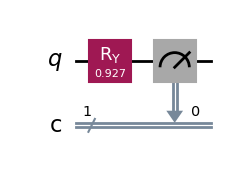

In [5]:
qc = QuantumCircuit(1, 1)
qc.ry(theta, 0)
qc.measure(0, 0)

print("Probabilidad ideal P(1):", math.sin(theta / 2) ** 2)
qc.draw("mpl")

## 6. Cargar Q-CTRL Performance Management


In [6]:
if QiskitFunctionsCatalog is None:
    raise RuntimeError(
        "No se puede cargar Q-CTRL porque falta qiskit_ibm_catalog. "
        "Instala qiskit-ibm-catalog y reinicia el kernel."
    )

try:
    catalog = QiskitFunctionsCatalog(channel=CHANNEL)
    perf_mgmt = catalog.load("q-ctrl/performance-management")
except Exception as exc:
    print("ERROR: no se pudo cargar q-ctrl/performance-management.")
    print(
        "Probablemente la cuenta no tiene habilitada la funcion de "
        "Q-CTRL Performance Management, o el plan/canal no permite Qiskit Functions."
    )
    print(f"Detalle: {type(exc).__name__}: {exc}")
    raise

print("Q-CTRL Performance Management cargado:", perf_mgmt)

Q-CTRL Performance Management cargado: QiskitFunction(q-ctrl/performance-management)


## 7. Ejecutar con Q-CTRL Sampler

In [7]:
force_qctrl_qpy_compat(QCTRL_QPY_COMPAT_VERSION)

qctrl_sampler_pubs = [(qc, None, SHOTS)]

try:
    qctrl_job = perf_mgmt.run(
        primitive="sampler",
        pubs=qctrl_sampler_pubs,
        backend_name=BACKEND_NAME,
    )
except Exception as exc:
    print("ERROR: fallo el envio del job Q-CTRL Sampler.")
    print(
        "Si el backend existe pero Q-CTRL lo rechaza, puede que ese backend "
        "no este soportado por Q-CTRL para tu cuenta o region."
    )
    print(f"Detalle: {type(exc).__name__}: {exc}")
    raise

print("Backend usado:", BACKEND_NAME)
print("Shots:", SHOTS)
print("Q-CTRL job id:", job_identifier(qctrl_job))

try:
    qctrl_result = qctrl_job.result()
except Exception as exc:
    print_qpy_error_hint(exc)
    raise

qctrl_counts = extract_counts(qctrl_result)
qctrl_p_hat = p_hat_from_counts(qctrl_counts, SHOTS)

print("Q-CTRL counts:", qctrl_counts)
print("Q-CTRL total shots recibidos:", sum(qctrl_counts.values()))
print("Q-CTRL p_hat = counts['1'] / shots:", qctrl_p_hat)

plot_histogram(qctrl_counts, title="Q-CTRL Sampler counts")

QPY local Qiskit: 14
QPY max usado para serializar hacia Q-CTRL: 13
Backend usado: ibm_basquecountry
Shots: 1024
Q-CTRL job id: 5b70f2f4-4a85-47bd-a79a-0d60b0288e12


QiskitServerlessException: ["embeddedqfcommons.types.QctrlQiskitFunctionError: 'Device ibm_basquecountry not found in the device registry.'\n"]

In [8]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(channel="ibm_quantum_platform")

print("Backends IBM Runtime disponibles:")
for backend in service.backends():
    print(backend.name)

Backends IBM Runtime disponibles:
ibm_basquecountry


## 8. Comparacion opcional: IBM Runtime SamplerV2 raw

Esta rama usa el mismo circuito logico, pero transpila una copia para el backend antes de llamar al `SamplerV2` estandar. Esto no afecta a la rama Q-CTRL.

Raw Runtime counts: {'0': 817, '1': 207}
Raw Runtime total shots recibidos: 1024
Raw Runtime p_hat = counts['1'] / shots: 0.2021484375


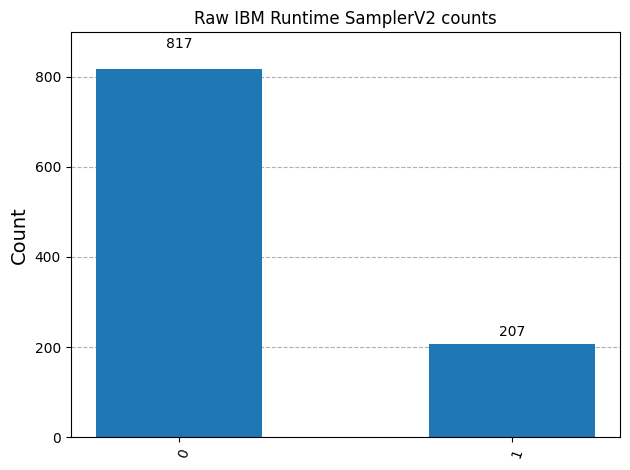

In [9]:
raw_counts = None
raw_p_hat = None
raw_job = None

if RUN_RAW_RUNTIME_COMPARISON:
    # Runtime SamplerV2 estandar espera circuitos compatibles con el ISA del backend.
    pass_manager = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
    )
    raw_isa_qc = pass_manager.run(qc.copy())

    print("Circuito raw transpilado para IBM Runtime SamplerV2")
    print("depth:", raw_isa_qc.depth())
    print("ops:", raw_isa_qc.count_ops())

    raw_sampler = Sampler(mode=backend)

    # Esta forma coincide con el uso estandar de Runtime SamplerV2 en el repo.
    # El fallback cubre entornos que prefieren PUBs explicitos.
    try:
        raw_job = raw_sampler.run([raw_isa_qc], shots=SHOTS)
    except TypeError:
        raw_job = raw_sampler.run([(raw_isa_qc, None, SHOTS)])

    print("Backend usado:", object_name(backend))
    print("Shots:", SHOTS)
    print("Raw Runtime job id:", job_identifier(raw_job))

    raw_result = raw_job.result()
    raw_counts = extract_counts(raw_result)
    raw_p_hat = p_hat_from_counts(raw_counts, SHOTS)

    print("Raw Runtime counts:", raw_counts)
    print("Raw Runtime total shots recibidos:", sum(raw_counts.values()))
    print("Raw Runtime p_hat = counts['1'] / shots:", raw_p_hat)

    display(plot_histogram(raw_counts, title="Raw IBM Runtime SamplerV2 counts"))
else:
    print("Comparacion raw desactivada: RUN_RAW_RUNTIME_COMPARISON = False")

## 9. Resumen de conteos

La salida se limita a conteos y probabilidad estimada. No hay likelihood normal, Estimator ni integracion con CABIQAE.

In [ ]:
print("Backend:", BACKEND_NAME)
print("Shots:", SHOTS)
print("Probabilidad ideal P(1):", math.sin(theta / 2) ** 2)
print()

print("Q-CTRL counts:", qctrl_counts)
print("Q-CTRL p_hat:", qctrl_p_hat)

if raw_counts is not None:
    print()
    print("Raw Runtime counts:", raw_counts)
    print("Raw Runtime p_hat:", raw_p_hat)
    display(
        plot_histogram(
            [raw_counts, qctrl_counts],
            legend=["raw Runtime", "Q-CTRL"],
            title="Counts raw vs Q-CTRL",
        )
    )

## Conexion posterior con el experimento de contraste de Grover

Despues, este flujo se puede conectar con nuestro experimento de contraste de Grover sin cambiar la semantica estadistica: para cada potencia `k`, se construiria el mismo circuito logico `C_k = Q^k A` que ya usa el pipeline raw. La rama raw seguiria nuestro pipeline actual de transpilacion, layout y `SamplerV2`; la rama Q-CTRL recibiria ese mismo circuito logico `C_k` sin pretranspilar mediante `perf_mgmt.run(primitive="sampler", pubs=[(C_k, None, shots_k)], backend_name=...)`.

La comparacion seria punto a punto en conteos y probabilidad estimada: `p_hat_k = counts_k["1"] / shots_k` para cada `k`. Asi se mide si Q-CTRL modifica el contraste observado de la senal amplificada, manteniendo iguales el circuito logico, el backend, el presupuesto de shots y la definicion de exito.